# Lab 2: Loss Functions & Gradient Descent

**Course:** DATA425 | Foundations of Deep Learning

**Prerequisite:** Lab 1 (Perceptrons & Forward Propagation)

---

## What This Lab Is About

In Lab 1, we built neural networks that could make predictions. But here's the problem: how does the network know if its prediction is any good? And once it knows it's wrong, how does it get better?

These are the two big ideas for this week:

1. **Loss functions**, a way to measure "how wrong" the network is (Parts 1–3)
2. **Gradient descent**, a strategy for improving the weights step by step (Part 4)

By the end of this lab, you'll understand the full training loop that makes deep learning work:

> **Make a prediction → Measure how wrong it is → Figure out which direction to adjust → Take a small step → Repeat**

### How to Work Through This Lab

- **Run every code cell** (Shift+Enter), even if you don't write any code, seeing the output is interesting and helpful!
- **Read the explanations** between code cells, they help connect the code to key concepts :)
- **Fill in the exercises**. These are marked with ✏️ and are where you practice
- **Don't panic about the code**. Focus on understanding the *concepts*. Keras will do the heavy lifting later! If you're taking COSC440 next sem, marinate in the code a little longer.

---
## Part 0: Setup

Run the cell below to import our tools. Nothing to change, just press **Shift+Enter**.

In [35]:
# Run this cell first! It loads all the tools we need.
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.patches import FancyArrowPatch
import warnings
warnings.filterwarnings('ignore')

# Make plots look nice
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 13
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("All set! Let's learn about loss functions and gradient descent.")

All set! Let's learn about loss functions and gradient descent.


---
## Part 1: Loss Functions for Regression: "How Wrong Are We?"

### The Big Idea

Imagine you're a teacher and your neural network is a student taking a test. The network makes predictions, and you need a way to grade those predictions, that is to turn "how wrong" into a single number.

That number is called the **loss** (also called the cost, error, or objective function). The key insight:

> **Loss measures a single prediction's error. The objective function averages the loss over ALL predictions.**

Let's start with the simplest case: **regression**, where the network predicts a number (like an exam score).

### Step 1.1: A Concrete Example

Consider this example. We're predicting exam scores based on two assignment scores:

| Student | Assignment 1 (x₁) | Assignment 2 (x₂) | Actual Exam (y) | Model Prediction (ŷ) |
|---------|-------------------|-------------------|-----------------|---------------------|
| A       | 80                | 90                | 80              | 76                  |
| B       | 60                | 40                | 20              | 2                   |
| C       | 75                | 20                | 70              | 82                  |

The model's predictions aren't perfect. But *how bad* are they? Let's compute it step by step.

In [36]:
# Sample data for exam score prediction
actual =      np.array([80, 20, 70])   # What the exam scores ACTUALLY were (y)
predicted =   np.array([76,  2, 82])   # What our model PREDICTED (ŷ)
students =    ['Student A', 'Student B', 'Student C']

# Step 1: How far off is each prediction?
errors = actual - predicted

print("Step 1: Raw errors (actual - predicted)")
print("=" * 50)
for name, y, yhat, err in zip(students, actual, predicted, errors):
    print(f"  {name}: {y} - {yhat} = {err:+d}")

print(f"\nSum of errors: {errors.sum()}")
print("\nHmm, the errors cancel out! +4 and -12 partially cancel the +18.")
print("That's misleading — Student B's prediction was TERRIBLE (off by 18!)")
print("We need a better approach...")

Step 1: Raw errors (actual - predicted)
  Student A: 80 - 76 = +4
  Student B: 20 - 2 = +18
  Student C: 70 - 82 = -12

Sum of errors: 10

Hmm, the errors cancel out! +4 and -12 partially cancel the +18.
That's misleading — Student B's prediction was TERRIBLE (off by 18!)
We need a better approach...


### Step 1.2: Mean Squared Error (MSE): The Standard Regression Loss

The solution: **square the errors first, then average them.** Squaring does two clever things:
1. Makes all errors positive (no more cancelling out)
2. **Punishes big errors much more than small ones** (recall: 324 vs 16!)

The formula is:

$$J(\mathbf{W}) = \frac{1}{n} \sum_{i=1}^{n} \left( \hat{y}^{(i)} - y^{(i)} \right)^2$$

Don't let the formula scare you! It just means "square each error, then take the average." Let's compute it:

In [37]:
# Step 2: Square the errors
squared_errors = errors ** 2

print("Step 2: Squared errors")
print("=" * 50)
for name, err, sq in zip(students, errors, squared_errors):
    print(f"  {name}: ({err:+d})² = {sq}")

print(f"\nNotice: Student B's squared error ({squared_errors[1]}) is MUCH bigger")
print(f"than Student A's ({squared_errors[0]}), even though A was also wrong.")
print(f"This is the key property: squaring penalises big errors MORE harshly!\n")

# Step 3: Average them
mse = squared_errors.mean()

print("Step 3: Average the squared errors (= MSE)")
print("=" * 50)
print(f"  MSE = (1/3) × ({squared_errors[0]} + {squared_errors[1]} + {squared_errors[2]})")
print(f"      = (1/3) × {squared_errors.sum()}")
print(f"      = {mse:.2f}")
print(f"\nThis is our objective function J(W) = {mse:.2f}")
print(f"Our goal in training: make this number as SMALL as possible!")

Step 2: Squared errors
  Student A: (+4)² = 16
  Student B: (+18)² = 324
  Student C: (-12)² = 144

Notice: Student B's squared error (324) is MUCH bigger
than Student A's (16), even though A was also wrong.
This is the key property: squaring penalises big errors MORE harshly!

Step 3: Average the squared errors (= MSE)
  MSE = (1/3) × (16 + 324 + 144)
      = (1/3) × 484
      = 161.33

This is our objective function J(W) = 161.33
Our goal in training: make this number as SMALL as possible!


### Step 1.3: Visualising Why Squaring Matters

Let's actually *see* why squaring the errors is such a good idea. We'll compare what happens with regular errors vs squared errors.

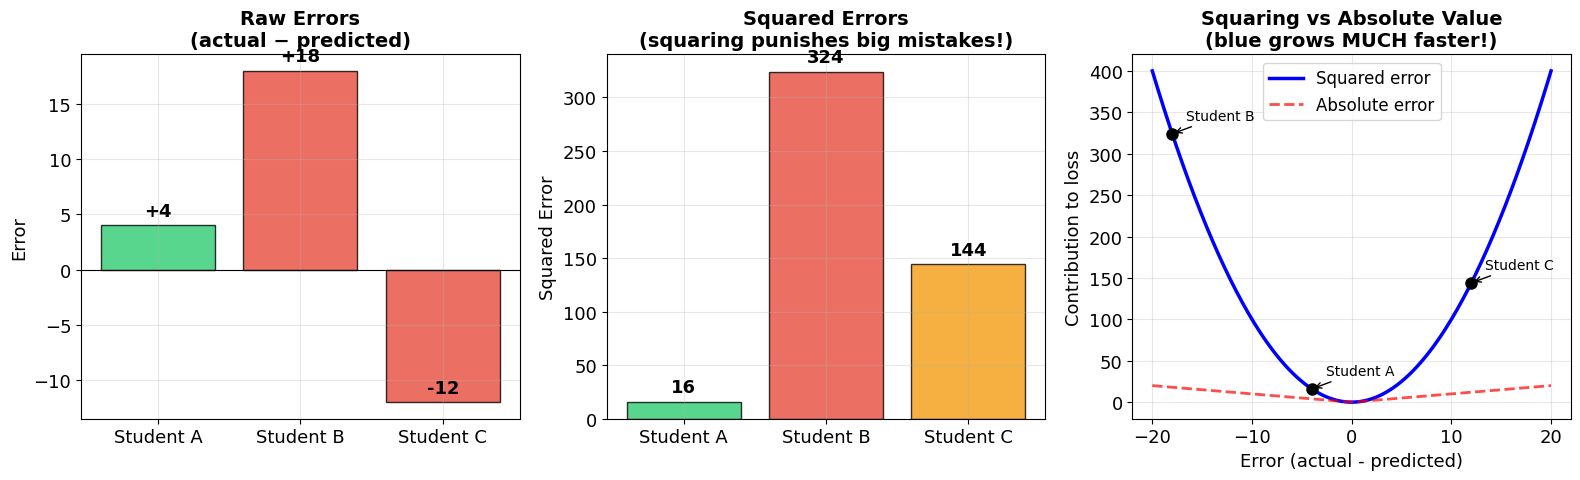


Key takeaway: the blue curve (squaring) grows much faster than the red
curve (absolute value). That's why MSE is 'harsh' on big mistakes!


In [38]:
# Visualise: the effect of squaring
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: The raw errors
ax = axes[0]
colors = ['#2ecc71' if abs(e) <= 5 else '#e74c3c' for e in errors]
bars = ax.bar(students, errors, color=colors, edgecolor='black', alpha=0.8)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title("Raw Errors\n(actual − predicted)", fontsize=14, fontweight='bold')
ax.set_ylabel("Error")
for bar, val in zip(bars, errors):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:+d}', ha='center', va='bottom', fontweight='bold')

# Plot 2: The squared errors
ax = axes[1]
colors = ['#2ecc71' if sq <= 30 else '#f39c12' if sq <= 200 else '#e74c3c' for sq in squared_errors]
bars = ax.bar(students, squared_errors, color=colors, edgecolor='black', alpha=0.8)
ax.set_title("Squared Errors\n(squaring punishes big mistakes!)", fontsize=14, fontweight='bold')
ax.set_ylabel("Squared Error")
for bar, val in zip(bars, squared_errors):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(val)), ha='center', va='bottom', fontweight='bold')

# Plot 3: The squaring function itself
ax = axes[2]
x_range = np.linspace(-20, 20, 200)
ax.plot(x_range, x_range**2, 'b-', linewidth=2.5, label='Squared error')
ax.plot(x_range, np.abs(x_range), 'r--', linewidth=2, alpha=0.7, label='Absolute error')
ax.set_xlabel("Error (actual - predicted)")
ax.set_ylabel("Contribution to loss")
ax.set_title("Squaring vs Absolute Value\n(blue grows MUCH faster!)", fontsize=14, fontweight='bold')
ax.legend(fontsize=12)

# Annotate key points
for err_val in [-18, -4, 12]:
    ax.plot(err_val, err_val**2, 'ko', markersize=8, zorder=5)
    label = {-18: 'B', -4: 'A', 12: 'C'}[err_val]
    ax.annotate(f'Student {label}', (err_val, err_val**2),
                textcoords="offset points", xytext=(10, 10), fontsize=10,
                arrowprops=dict(arrowstyle='->', color='black'))

plt.tight_layout()
plt.savefig('part1_mse_visual.png', dpi=100, bbox_inches='tight')
plt.show()
print("\nKey takeaway: the blue curve (squaring) grows much faster than the red")
print("curve (absolute value). That's why MSE is 'harsh' on big mistakes!")

---
### ✏️ Exercise 1: Compute MSE Yourself

A model makes the following predictions. **Compute the MSE by hand first**, then check with code.

| Sample | Actual (y) | Predicted (ŷ) |
|--------|-----------|---------------|
| 1      | 10        | 12            |
| 2      | 5         | 5             |
| 3      | 8         | 3             |
| 4      | 15        | 14            |

**Your hand calculation** (fill this in):
- Error for sample 1: 10 - 12 = ___
- Squared error for sample 1: ___
- (continue for all 4...)
- MSE = average of squared errors = ___

In [39]:
# EXERCISE 1: Check your hand calculation with code
# Fill in the arrays, then run this cell

actual_ex1 =    np.array([10, 5, 8, 15])
predicted_ex1 = np.array([12, 5, 3, 14])

# Compute MSE step by step (fill in the blanks)
errors_ex1 = actual_ex1 - predicted_ex1           # Step 1: raw errors
squared_errors_ex1 = errors_ex1 ** 2               # Step 2: square them
mse_ex1 = squared_errors_ex1.mean()                # Step 3: average

print("Your errors:", errors_ex1)
print("Squared errors:", squared_errors_ex1)
print(f"MSE = {mse_ex1}")
print(f"\nDoes this match your hand calculation?")
print(f"\nWhich sample contributes the MOST to the loss? Why?")

Your errors: [-2  0  5  1]
Squared errors: [ 4  0 25  1]
MSE = 7.5

Does this match your hand calculation?

Which sample contributes the MOST to the loss? Why?


In [40]:
# EXERCISE 1 continued: Write your answer here
#
# The sample that contributes the most to the loss is sample ___
# because...
#
# In your own words, what does MSE measure?
#
# 

---
## Part 2: Loss for Classification: "How Confident and Correct Are We?"

### Why MSE Doesn't Work for Classification

For regression, MSE works great since we're measuring the distance between numbers. But what about **classification**, where we're predicting categories (like "cat" or "not cat")?

The problem is that classification outputs are **probabilities**, that is, numbers between 0 and 1. And it turns out MSE behaves badly with probabilities. Let's see why:

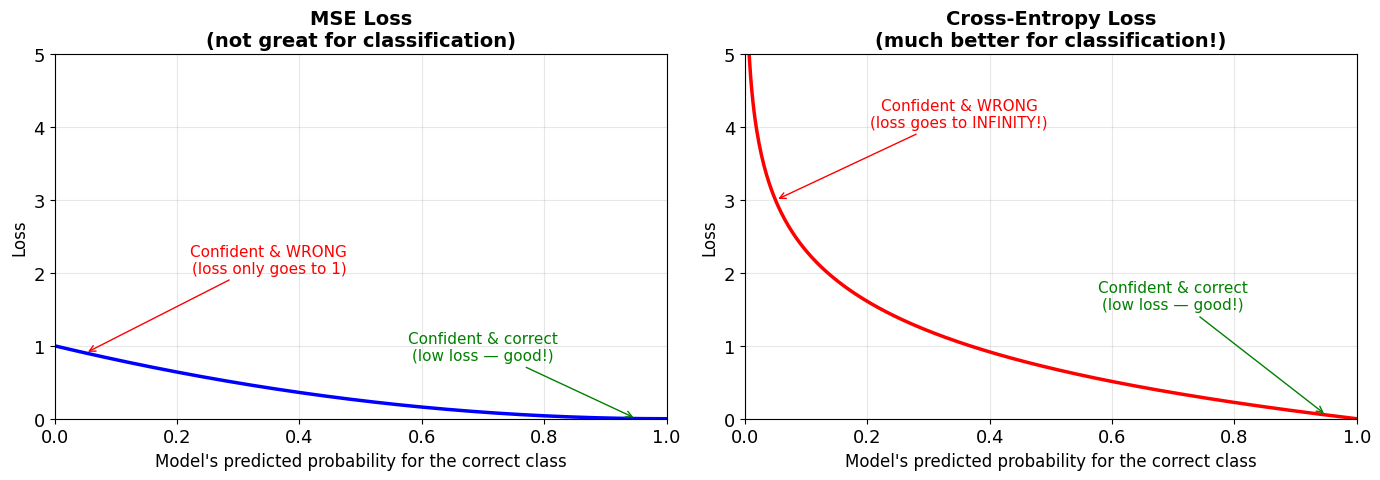

Key insight: Cross-entropy REALLY punishes confident wrong answers!
If the model says 'I'm 99% sure this is a cat' and it's actually a dog,
cross-entropy assigns a HUGE penalty. MSE would barely care.


In [41]:
# Why MSE is bad for classification: a visual story

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Generate predicted probabilities
p = np.linspace(0.001, 0.999, 500)

# Scenario: the true label is 1 (positive class)
# MSE loss when true = 1
mse_loss = (1 - p) ** 2

# Binary cross-entropy when true = 1
bce_loss = -np.log(p)

# Plot MSE
ax = axes[0]
ax.plot(p, mse_loss, 'b-', linewidth=2.5)
ax.set_xlabel("Model's predicted probability for the correct class", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title("MSE Loss\n(not great for classification)", fontsize=14, fontweight='bold')
ax.set_xlim(0, 1)
ax.set_ylim(0, 5)

# Annotate
ax.annotate('Confident & correct\n(low loss — good!)', xy=(0.95, 0.0025),
            fontsize=11, color='green', ha='center',
            xytext=(0.7, 0.8), arrowprops=dict(arrowstyle='->', color='green'))
ax.annotate('Confident & WRONG\n(loss only goes to 1)', xy=(0.05, 0.9),
            fontsize=11, color='red', ha='center',
            xytext=(0.35, 2.0), arrowprops=dict(arrowstyle='->', color='red'))

# Plot BCE
ax = axes[1]
ax.plot(p, bce_loss, 'r-', linewidth=2.5)
ax.set_xlabel("Model's predicted probability for the correct class", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title("Cross-Entropy Loss\n(much better for classification!)", fontsize=14, fontweight='bold')
ax.set_xlim(0, 1)
ax.set_ylim(0, 5)

# Annotate
ax.annotate('Confident & correct\n(low loss — good!)', xy=(0.95, 0.05),
            fontsize=11, color='green', ha='center',
            xytext=(0.7, 1.5), arrowprops=dict(arrowstyle='->', color='green'))
ax.annotate('Confident & WRONG\n(loss goes to INFINITY!)', xy=(0.05, 3.0),
            fontsize=11, color='red', ha='center',
            xytext=(0.35, 4.0), arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.savefig('part2_mse_vs_bce.png', dpi=100, bbox_inches='tight')
plt.show()

print("Key insight: Cross-entropy REALLY punishes confident wrong answers!")
print("If the model says 'I'm 99% sure this is a cat' and it's actually a dog,")
print("cross-entropy assigns a HUGE penalty. MSE would barely care.")

### Step 2.1: Binary Cross-Entropy: Loss for Yes/No Questions

For problems with **two classes** (spam or not spam, cat or dog, pass or fail), we use **binary cross-entropy**:

$$\mathcal{L} = -\Big[ y \cdot \log(\hat{y}) + (1-y) \cdot \log(1 - \hat{y}) \Big]$$

This looks scary, but let's break it down. There are really just two cases:

**Case 1: The true label is 1** (it IS a cat)
→ The formula simplifies to: $\mathcal{L} = -\log(\hat{y})$
→ Translation: "How much probability did you give to the right answer?"

**Case 2: The true label is 0** (it is NOT a cat)
→ The formula simplifies to: $\mathcal{L} = -\log(1 - \hat{y})$
→ Translation: "How much probability did you give to the right answer?"

In both cases: **the more confident you are about the RIGHT answer, the lower the loss.** Let's see this in action:

In [42]:
# Binary cross-entropy: step-by-step examples

def binary_cross_entropy(y_true, y_pred):
    """Compute binary cross-entropy for one example."""
    return -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

print("Example: Is this email spam?")
print("=" * 60)
print()

# Case 1: It IS spam (y = 1)
print("Case 1: The email IS spam (y = 1)")
print("-" * 40)
for pred in [0.9, 0.7, 0.5, 0.3, 0.1]:
    loss = binary_cross_entropy(1, pred)
    quality = "Excellent!" if loss < 0.2 else "Good" if loss < 0.5 else "Bad" if loss < 1.5 else "Terrible!"
    bar = "█" * int(loss * 10)
    print(f"  Model says P(spam) = {pred:.1f} → Loss = {loss:.3f} {bar} {quality}")

print()

# Case 2: It is NOT spam (y = 0)
print("Case 2: The email is NOT spam (y = 0)")
print("-" * 40)
for pred in [0.1, 0.3, 0.5, 0.7, 0.9]:
    loss = binary_cross_entropy(0, pred)
    quality = "Excellent!" if loss < 0.2 else "Good" if loss < 0.5 else "Bad" if loss < 1.5 else "Terrible!"
    bar = "█" * int(loss * 10)
    print(f"  Model says P(spam) = {pred:.1f} → Loss = {loss:.3f} {bar} {quality}")

print()
print("Pattern: the loss is LOW when the model is confident about the RIGHT answer,")
print("and HIGH when the model is confident about the WRONG answer.")

Example: Is this email spam?

Case 1: The email IS spam (y = 1)
----------------------------------------
  Model says P(spam) = 0.9 → Loss = 0.105 █ Excellent!
  Model says P(spam) = 0.7 → Loss = 0.357 ███ Good
  Model says P(spam) = 0.5 → Loss = 0.693 ██████ Bad
  Model says P(spam) = 0.3 → Loss = 1.204 ████████████ Bad
  Model says P(spam) = 0.1 → Loss = 2.303 ███████████████████████ Terrible!

Case 2: The email is NOT spam (y = 0)
----------------------------------------
  Model says P(spam) = 0.1 → Loss = 0.105 █ Excellent!
  Model says P(spam) = 0.3 → Loss = 0.357 ███ Good
  Model says P(spam) = 0.5 → Loss = 0.693 ██████ Bad
  Model says P(spam) = 0.7 → Loss = 1.204 ████████████ Bad
  Model says P(spam) = 0.9 → Loss = 2.303 ███████████████████████ Terrible!

Pattern: the loss is LOW when the model is confident about the RIGHT answer,
and HIGH when the model is confident about the WRONG answer.


---
## Part 3: Multi-Class Classification: Softmax and Cross-Entropy

### The Cat/Panda/Koala Example

We have a network that looks at an image and needs to decide if it's a cat, a panda, or a koala. The network's output layer has **three nodes**, one for each class.

But here's the problem: the raw outputs of the network (before activation) could be any numbers, like `[2.1, 0.5, -1.3]`. These aren't probabilities! We need them to:
1. All be between 0 and 1
2. All add up to 1 (since the image has to be SOMETHING)

That's exactly what **softmax** does.

In [43]:
# Softmax: turning raw scores into probabilities

def softmax(z):
    """Convert raw scores into probabilities that sum to 1."""
    exp_z = np.exp(z - np.max(z))  # subtract max for numerical stability
    return exp_z / exp_z.sum()

# Example: the network's raw outputs for a cat image
raw_scores = np.array([2.1, 0.5, -1.3])
classes = ['Cat', 'Panda', 'Koala']

print("Softmax: Turning Scores into Probabilities")
print("=" * 55)
print()
print("Step 1: The network produces raw scores (called 'logits'):")
for cls, score in zip(classes, raw_scores):
    print(f"  {cls:8s}: {score:+.1f}")

print(f"\nThese aren't probabilities — they don't sum to 1, and some are negative!")
print(f"Sum of raw scores: {raw_scores.sum():.1f}")

print(f"\nStep 2: Apply softmax (e^score for each, then divide by the total):")
exp_scores = np.exp(raw_scores)
for cls, score, exp_s in zip(classes, raw_scores, exp_scores):
    print(f"  {cls:8s}: e^{score:+.1f} = {exp_s:.3f}")
print(f"  Total: {exp_scores.sum():.3f}")

probabilities = softmax(raw_scores)
print(f"\nStep 3: Divide each by the total to get probabilities:")
for cls, prob in zip(classes, probabilities):
    bar = "█" * int(prob * 40)
    print(f"  P({cls:8s} | image) = {prob:.3f}  {bar}")
print(f"  Sum of probabilities: {probabilities.sum():.3f} ✓ (always sums to 1!)")

Softmax: Turning Scores into Probabilities

Step 1: The network produces raw scores (called 'logits'):
  Cat     : +2.1
  Panda   : +0.5
  Koala   : -1.3

These aren't probabilities — they don't sum to 1, and some are negative!
Sum of raw scores: 1.3

Step 2: Apply softmax (e^score for each, then divide by the total):
  Cat     : e^+2.1 = 8.166
  Panda   : e^+0.5 = 1.649
  Koala   : e^-1.3 = 0.273
  Total: 10.087

Step 3: Divide each by the total to get probabilities:
  P(Cat      | image) = 0.810  ████████████████████████████████
  P(Panda    | image) = 0.163  ██████
  P(Koala    | image) = 0.027  █
  Sum of probabilities: 1.000 ✓ (always sums to 1!)


### Step 3.1: One-Hot Encoding: The "True Answer"

The true label for a cat image is represented as a **one-hot vector**: `[1, 0, 0]`

This means "100% cat, 0% panda, 0% koala", the ideal output we want the network to eventually produce.

In [44]:
# One-hot encoding: representing the true answer

print("One-Hot Encoding: The True Answer")
print("=" * 55)
print()
print("If the image is a CAT, the true label is:    [1, 0, 0]")
print("If the image is a PANDA, the true label is:  [0, 1, 0]")
print("If the image is a KOALA, the true label is:  [0, 0, 1]")
print()
print("Our network's prediction:  ", [f"{p:.3f}" for p in probabilities])
print("The true label (it's a cat):", [1, 0, 0])
print()
print("The network gives cat a probability of {:.1%} — not bad, but not perfect!".format(probabilities[0]))
print("A perfect network would output [1.000, 0.000, 0.000]")

One-Hot Encoding: The True Answer

If the image is a CAT, the true label is:    [1, 0, 0]
If the image is a PANDA, the true label is:  [0, 1, 0]
If the image is a KOALA, the true label is:  [0, 0, 1]

Our network's prediction:   ['0.810', '0.163', '0.027']
The true label (it's a cat): [1, 0, 0]

The network gives cat a probability of 81.0% — not bad, but not perfect!
A perfect network would output [1.000, 0.000, 0.000]


### Step 3.2: Cross-Entropy Loss for Multi-Class

For multi-class classification, the loss is:

$$\mathcal{L} = -\log(\text{probability the model assigned to the correct class})$$

That's it! We just look at how much probability the model gave to the **right answer**, and take the negative log. For example, for a cat image where the model predicted P(cat) = 0.6:

$$\mathcal{L} = -\log(0.6) \approx 0.51$$

In [45]:
# Cross-entropy loss: how wrong is our multi-class prediction?

print("Cross-Entropy Loss Calculation")
print("=" * 55)

# The true class is "cat" (index 0)
true_class = 0
true_class_prob = probabilities[true_class]

loss = -np.log(true_class_prob)

print(f"\nThe true class is: {classes[true_class]}")
print(f"Our model gave {classes[true_class]} a probability of: {true_class_prob:.4f}")
print(f"\nCross-entropy loss = -log({true_class_prob:.4f}) = {loss:.4f}")
print()

# Now show what happens with different confidence levels
print("\nWhat if the model were more or less confident about 'cat'?")
print("-" * 55)
for p_cat in [0.99, 0.9, 0.6, 0.33, 0.1, 0.01]:
    ce = -np.log(p_cat)
    bar = "█" * int(min(ce * 5, 30))
    emoji = "🟢" if ce < 0.3 else "🟡" if ce < 1.0 else "🔴"
    print(f"  P(cat) = {p_cat:.2f} → Loss = {ce:.3f}  {bar}")

print()
print("The pattern: loss approaches 0 when we're very confident about the right answer,")
print("and shoots toward infinity when we give the right answer very low probability.")
print("\nThis matches L = -log(0.6) from earlier!")

Cross-Entropy Loss Calculation

The true class is: Cat
Our model gave Cat a probability of: 0.8095

Cross-entropy loss = -log(0.8095) = 0.2113


What if the model were more or less confident about 'cat'?
-------------------------------------------------------
  P(cat) = 0.99 → Loss = 0.010  
  P(cat) = 0.90 → Loss = 0.105  
  P(cat) = 0.60 → Loss = 0.511  ██
  P(cat) = 0.33 → Loss = 1.109  █████
  P(cat) = 0.10 → Loss = 2.303  ███████████
  P(cat) = 0.01 → Loss = 4.605  ███████████████████████

The pattern: loss approaches 0 when we're very confident about the right answer,
and shoots toward infinity when we give the right answer very low probability.

This is exactly what the lecture showed with L = -log(0.6)!


---
### ✏️ Exercise 2: Compute Cross-Entropy Yourself

The network looks at three images and produces the following softmax outputs:

| Image | P(cat) | P(panda) | P(koala) | True Class |
|-------|--------|----------|----------|------------|
| 1     | 0.7    | 0.2      | 0.1      | Cat        |
| 2     | 0.1    | 0.8      | 0.1      | Panda      |
| 3     | 0.3    | 0.3      | 0.4      | Koala      |

**By hand**, compute:
1. The cross-entropy loss for each image
2. The average cross-entropy (the objective function J(W))

**Hint:** For each image, find the probability assigned to the TRUE class, then compute -log(that probability).

In [46]:
# EXERCISE 2: Check your answers

# Image 1: True class = Cat, P(cat) = 0.7
loss_1 = -np.log(0.7)

# Image 2: True class = Panda, P(panda) = 0.8
loss_2 = -np.log(0.8)

# Image 3: True class = Koala, P(koala) = 0.4
loss_3 = -np.log(0.4)

# Average (objective function)
avg_loss = (loss_1 + loss_2 + loss_3) / 3

print("Cross-entropy for each image:")
print(f"  Image 1 (cat):   -log(0.7) = {loss_1:.4f}")
print(f"  Image 2 (panda): -log(0.8) = {loss_2:.4f}")
print(f"  Image 3 (koala): -log(0.4) = {loss_3:.4f}")
print(f"\nObjective function J(W) = average = {avg_loss:.4f}")
print(f"\nWhich image had the highest loss? Which had the lowest? Why?")

Cross-entropy for each image:
  Image 1 (cat):   -log(0.7) = 0.3567
  Image 2 (panda): -log(0.8) = 0.2231
  Image 3 (koala): -log(0.4) = 0.9163

Objective function J(W) = average = 0.4987

Which image had the highest loss? Which had the lowest? Why?


In [47]:
# EXERCISE 2 continued: Write your answer here
#
# Image ___ had the highest loss because...
#
# Image ___ had the lowest loss because...
#
# In your own words, what does cross-entropy measure?
#
# 

---
## Part 4: Gradient Descent: Rolling Downhill to Find Better Weights

### The Big Question

We now know how to measure how wrong our network is (that's the loss). The next question:

> **"How can we use the loss information to get better weights?"**

And the answer is **gradient descent**, the most important optimisation algorithm in deep learning.

### The Intuition: Imagine You're Lost on a Mountain in Fog

Here's a useful analogy. Imagine:
- You're standing on a hilly landscape (the **loss surface**)
- Your position is the current set of **weights**
- Your altitude is the **loss** (how wrong the model is)
- You want to get to the **lowest point** (smallest loss = best weights)
- But you're in fog, so you can only feel the slope right where you're standing

**What do you do?** You feel which direction goes downhill, and take a step that way. Then repeat!

That "feeling the slope" is computing the **derivative** (gradient). Let's visualise this:

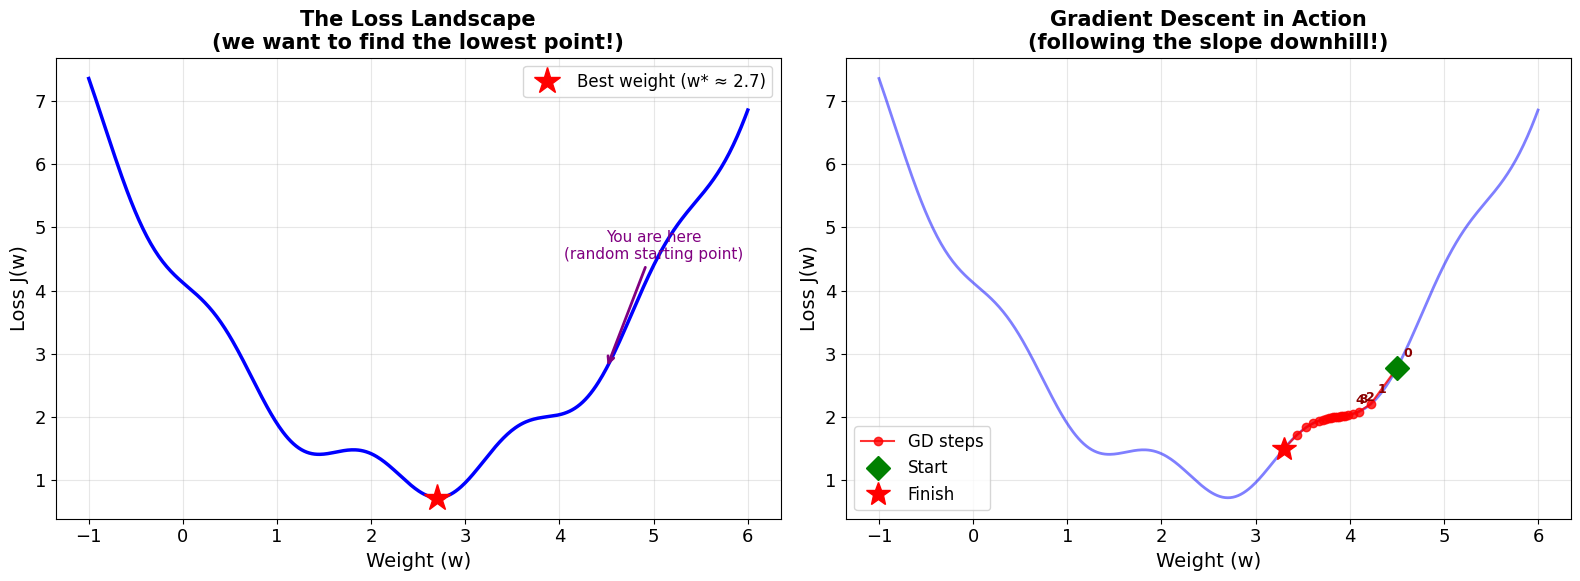

Watch how gradient descent takes big steps when the slope is steep,
and smaller steps as it approaches the bottom — just like the lecture showed!


In [48]:
# Visualise gradient descent on a simple 1D loss function
# Simplified to one weight for visualisation

def loss_function(w):
    """A bumpy loss function with one weight — a simple landscape to visualise."""
    return 0.5 * (w - 2.5)**2 + 0.3 * np.sin(4 * w) + 1

def loss_gradient(w):
    """The derivative (slope) of our loss function."""
    return (w - 2.5) + 0.3 * 4 * np.cos(4 * w)

# Plot the loss landscape
w_range = np.linspace(-1, 6, 500)
loss_values = loss_function(w_range)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: the loss landscape with the minimum marked
ax = axes[0]
ax.plot(w_range, loss_values, 'b-', linewidth=2.5)
ax.set_xlabel("Weight (w)", fontsize=14)
ax.set_ylabel("Loss J(w)", fontsize=14)
ax.set_title("The Loss Landscape\n(we want to find the lowest point!)", fontsize=15, fontweight='bold')

# Mark the minimum
w_min = w_range[np.argmin(loss_values)]
ax.plot(w_min, loss_function(w_min), 'r*', markersize=20, label=f'Best weight (w* ≈ {w_min:.1f})')
ax.legend(fontsize=12)

# Add the "fog" metaphor
ax.annotate('You are here\n(random starting point)', xy=(4.5, loss_function(4.5)),
            fontsize=11, ha='center', color='purple',
            xytext=(5, 4.5), arrowprops=dict(arrowstyle='->', color='purple', lw=2))

# Right: show gradient descent steps
ax = axes[1]
ax.plot(w_range, loss_values, 'b-', linewidth=2, alpha=0.5)
ax.set_xlabel("Weight (w)", fontsize=14)
ax.set_ylabel("Loss J(w)", fontsize=14)
ax.set_title("Gradient Descent in Action\n(following the slope downhill!)", fontsize=15, fontweight='bold')

# Simulate gradient descent
w = 4.5  # starting point
learning_rate = 0.1
path = [(w, loss_function(w))]

for i in range(20):
    grad = loss_gradient(w)
    w = w - learning_rate * grad
    path.append((w, loss_function(w)))

# Plot the path
path = np.array(path)
ax.plot(path[:, 0], path[:, 1], 'ro-', markersize=6, linewidth=1.5, alpha=0.8, label='GD steps')
ax.plot(path[0, 0], path[0, 1], 'gD', markersize=12, label='Start', zorder=5)
ax.plot(path[-1, 0], path[-1, 1], 'r*', markersize=18, label='Finish', zorder=5)
ax.legend(fontsize=12)

# Add step numbers for first few steps
for i in range(min(5, len(path))):
    ax.annotate(f'{i}', (path[i, 0], path[i, 1]),
                textcoords="offset points", xytext=(5, 8), fontsize=9,
                fontweight='bold', color='darkred')

plt.tight_layout()
plt.savefig('part4_gradient_descent.png', dpi=100, bbox_inches='tight')
plt.show()

print("Watch how gradient descent takes big steps when the slope is steep,")
print("and smaller steps as it approaches the bottom, just as expected!")

### Step 4.1: The Update Rule: One Simple Equation

The gradient descent update rule is:

$$w_{\text{new}} = w_{\text{old}} - \alpha \cdot \frac{\partial J}{\partial w}$$

In plain English:
- Look at the **slope** (derivative) where you are
- If the slope is positive (going uphill to the right), step **left** (decrease w)
- If the slope is negative (going downhill to the right), step **right** (increase w)
- The **learning rate** (α) controls how big each step is

Let's step through this manually:

In [49]:
# Step through gradient descent manually — see every step!

w = 4.5  # starting point (random initial weight)
learning_rate = 0.1

print("Manual Gradient Descent — Step by Step")
print("=" * 70)
print(f"Starting weight: w = {w}")
print(f"Learning rate: α = {learning_rate}")
print(f"Update rule: w_new = w_old - α × slope")
print(f"{'='*70}")
print(f"{'Step':>4s} | {'w':>7s} | {'Loss J(w)':>10s} | {'Slope':>8s} | {'Step Size':>10s} | {'New w':>7s}")
print(f"{'-'*70}")

for step in range(10):
    loss = loss_function(w)
    grad = loss_gradient(w)
    step_size = learning_rate * grad
    w_new = w - step_size

    direction = "← (go left)" if grad > 0 else "→ (go right)"
    print(f"{step:4d} | {w:7.3f} | {loss:10.4f} | {grad:+8.4f} | {step_size:+10.4f} | {w_new:7.3f}  {direction}")

    w = w_new

print(f"{'-'*70}")
print(f"\nAfter 10 steps: w = {w:.3f}, Loss = {loss_function(w):.4f}")
print(f"\nNotice how:")
print(f"  • The slope is POSITIVE early on → we step LEFT (decrease w)")
print(f"  • The steps get SMALLER as we approach the bottom (slope flattens out)")
print(f"  • The loss keeps decreasing — the network is learning!")

Manual Gradient Descent — Step by Step
Starting weight: w = 4.5
Learning rate: α = 0.1
Update rule: w_new = w_old - α × slope
Step |       w |  Loss J(w) |    Slope |  Step Size |   New w
----------------------------------------------------------------------
   0 |   4.500 |     2.7747 |  +2.7924 |    +0.2792 |   4.221  ← (go left)
   1 |   4.221 |     2.2037 |  +1.2582 |    +0.1258 |   4.095  ← (go left)
   2 |   4.095 |     2.0852 |  +0.6557 |    +0.0656 |   4.029  ← (go left)
   3 |   4.029 |     2.0500 |  +0.4286 |    +0.0429 |   3.987  ← (go left)
   4 |   3.987 |     2.0341 |  +0.3204 |    +0.0320 |   3.954  ← (go left)
   5 |   3.954 |     2.0248 |  +0.2617 |    +0.0262 |   3.928  ← (go left)
   6 |   3.928 |     2.0185 |  +0.2283 |    +0.0228 |   3.905  ← (go left)
   7 |   3.905 |     2.0135 |  +0.2099 |    +0.0210 |   3.884  ← (go left)
   8 |   3.884 |     2.0092 |  +0.2018 |    +0.0202 |   3.864  ← (go left)
   9 |   3.864 |     2.0051 |  +0.2018 |    +0.0202 |   3.844  ← (

### Step 4.2: The Learning Rate: How Big Are Our Steps?

The **learning rate** (α) is arguably one of the most important variables to choose. Let's see what happens with different learning rates:

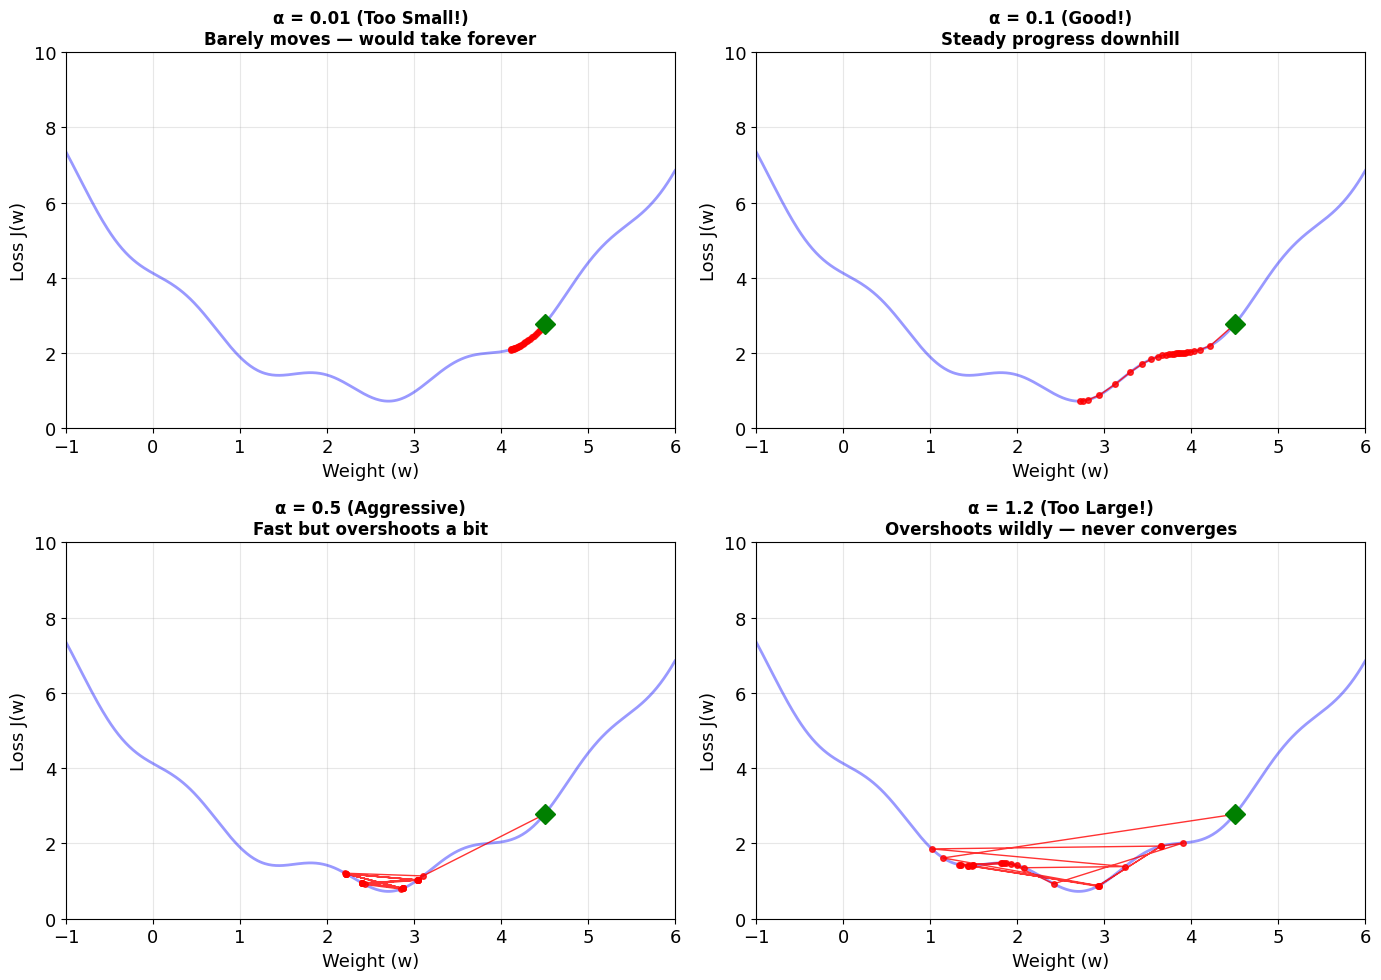

Key takeaways about learning rate:
  • Too small (0.01): very slow training, might not finish in time
  • Just right (0.1): steady progress, converges reliably
  • Too large (1.2): overshoots the minimum, might DIVERGE (loss goes UP!)

Finding a good learning rate is one of the most important skills in deep learning!


In [50]:
# The effect of learning rate — the most important hyperparameter!

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
learning_rates = [0.01, 0.1, 0.5, 1.2]
titles = [
    "α = 0.01 (Too Small!)\nBarely moves — would take forever",
    "α = 0.1 (Good!)\nSteady progress downhill",
    "α = 0.5 (Aggressive)\nFast but overshoots a bit",
    "α = 1.2 (Too Large!)\nOvershoots wildly — never converges"
]

for idx, (lr, title) in enumerate(zip(learning_rates, titles)):
    ax = axes[idx // 2, idx % 2]

    # Plot loss landscape
    ax.plot(w_range, loss_values, 'b-', linewidth=2, alpha=0.4)

    # Run gradient descent
    w = 4.5
    path = [(w, loss_function(w))]
    for _ in range(25):
        grad = loss_gradient(w)
        w = w - lr * grad
        w = np.clip(w, -2, 8)  # prevent going off the chart
        path.append((w, loss_function(w)))

    path = np.array(path)
    ax.plot(path[:, 0], path[:, 1], 'ro-', markersize=4, linewidth=1, alpha=0.8)
    ax.plot(path[0, 0], path[0, 1], 'gD', markersize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("Weight (w)")
    ax.set_ylabel("Loss J(w)")
    ax.set_ylim(0, 10)
    ax.set_xlim(-1, 6)

plt.tight_layout()
plt.savefig('part4_learning_rates.png', dpi=100, bbox_inches='tight')
plt.show()

print("Key takeaways about learning rate:")
print("  • Too small (0.01): very slow training, might not finish in time")
print("  • Just right (0.1): steady progress, converges reliably")
print("  • Too large (1.2): overshoots the minimum, might DIVERGE (loss goes UP!)")
print("\nFinding a good learning rate is one of the most important skills in deep learning!")

---
### ✏️ Exercise 3: Experiment with Gradient Descent

Try different starting points and learning rates. Answer the questions below.

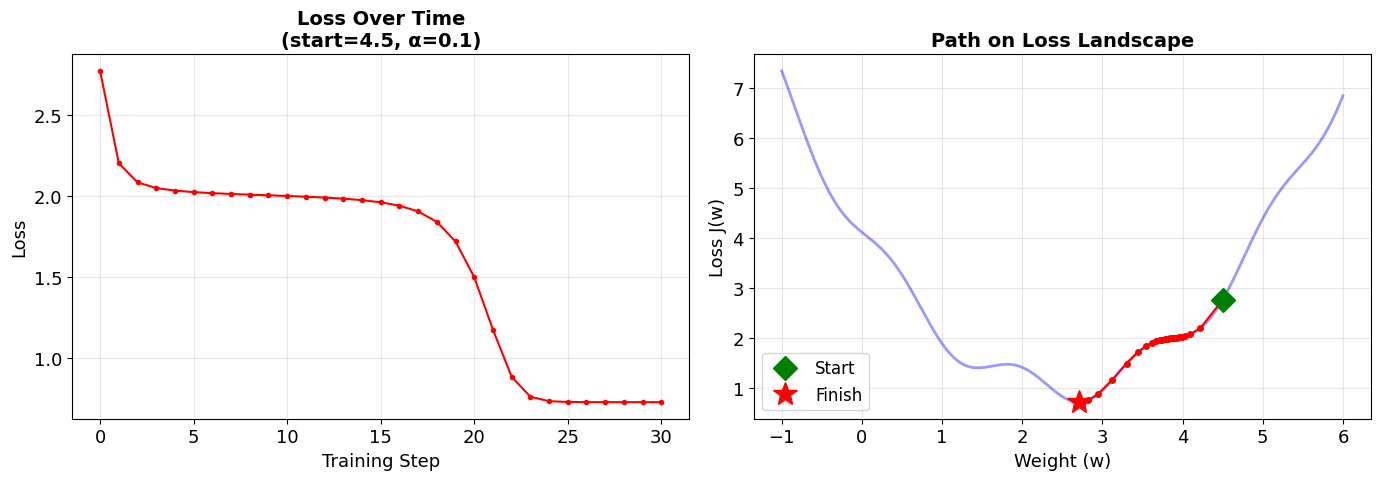

Final weight: 2.7061
Final loss: 0.7256


In [51]:
# EXERCISE 3: Change these values and re-run!

starting_weight = 4.5       # ← Try: -0.5, 0.0, 2.0, 4.5
learning_rate_ex3 = 0.1     # ← Try: 0.001, 0.01, 0.1, 0.5, 1.0
num_steps = 30

# Run gradient descent
w = starting_weight
losses_over_time = []

for step in range(num_steps):
    losses_over_time.append(loss_function(w))
    grad = loss_gradient(w)
    w = w - learning_rate_ex3 * grad

losses_over_time.append(loss_function(w))

# Plot: loss over training steps (this is what you'll see in real training!)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(losses_over_time, 'r-o', markersize=3, linewidth=1.5)
ax.set_xlabel("Training Step", fontsize=13)
ax.set_ylabel("Loss", fontsize=13)
ax.set_title(f"Loss Over Time\n(start={starting_weight}, α={learning_rate_ex3})",
             fontsize=14, fontweight='bold')

ax = axes[1]
ax.plot(w_range, loss_values, 'b-', linewidth=2, alpha=0.4)
# Re-run to get path
w = starting_weight
path = [(w, loss_function(w))]
for _ in range(num_steps):
    grad = loss_gradient(w)
    w = w - learning_rate_ex3 * grad
    path.append((w, loss_function(w)))
path = np.array(path)
ax.plot(path[:, 0], path[:, 1], 'ro-', markersize=4)
ax.plot(path[0, 0], path[0, 1], 'gD', markersize=12, label='Start')
ax.plot(path[-1, 0], path[-1, 1], 'r*', markersize=18, label='Finish')
ax.set_xlabel("Weight (w)", fontsize=13)
ax.set_ylabel("Loss J(w)", fontsize=13)
ax.set_title("Path on Loss Landscape", fontsize=14, fontweight='bold')
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

print(f"Final weight: {w:.4f}")
print(f"Final loss: {loss_function(w):.4f}")

In [52]:
# EXERCISE 3: Write your observations here
#
# When the learning rate is very small (0.001):
#   What happens to the loss curve?
#
#
# When the learning rate is very large (1.0):
#   What happens to the loss curve?
#
#
# When starting at different points (try -0.5 vs 4.5):
#   Do you always end up at the same place? Why or why not?
#   (Hint: think about the "local minimum" concept)
#
# 

---
## Part 5: Putting It All Together with Keras

### The Big Picture

The full training loop is:

1. **Forward pass**: push data through the network to get predictions
2. **Compute loss**: measure how wrong the predictions are (MSE or cross-entropy)
3. **Backward pass**: figure out which direction to adjust each weight (gradient)
4. **Update weights**: take a step downhill (gradient descent)
5. **Repeat** thousands of times!

The great news: **Keras handles all of this for us!** Let's see how the concepts we just learned map directly to Keras code.

### Step 5.1: Regression: Predicting House Prices

Let's start with a regression problem using MSE loss (from Part 1):

In [53]:
# Import Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Suppress TF warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)

print(f"TensorFlow version: {tf.__version__}")
print("\nKeras is a high-level library that")
print("takes care of the forward pass, loss, backpropagation, and gradient descent for us!")

TensorFlow version: 2.20.0

Remember from the lecture: Keras is a high-level library that
takes care of the forward pass, loss, backpropagation, and gradient descent for us!


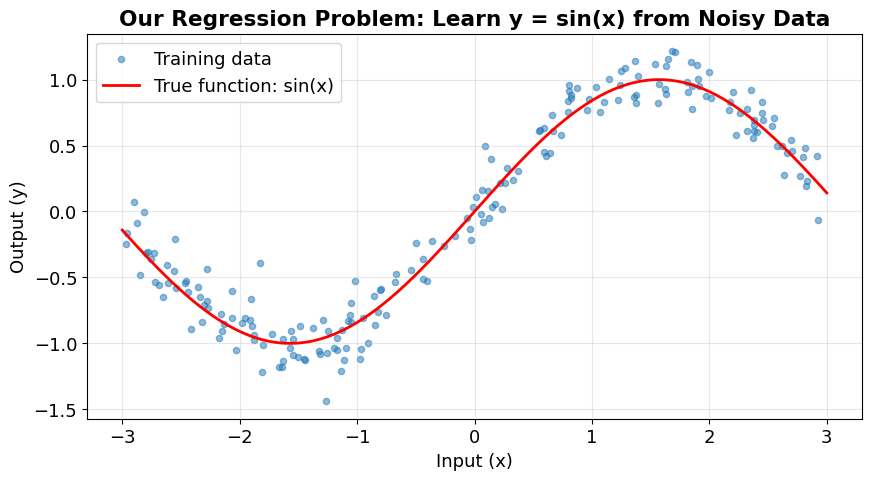

We want the network to discover the sine wave pattern from this noisy data!


In [54]:
# === REGRESSION EXAMPLE: Predicting values from a noisy sine wave ===

# Generate some data: y = sin(x) + noise (a regression problem!)
np.random.seed(42)
X_reg = np.random.uniform(-3, 3, 200).reshape(-1, 1)
y_reg = np.sin(X_reg) + np.random.normal(0, 0.15, X_reg.shape)

# Visualise
plt.figure(figsize=(10, 5))
plt.scatter(X_reg, y_reg, alpha=0.5, s=20, label='Training data')
x_smooth = np.linspace(-3, 3, 200).reshape(-1, 1)
plt.plot(x_smooth, np.sin(x_smooth), 'r-', linewidth=2, label='True function: sin(x)')
plt.xlabel("Input (x)")
plt.ylabel("Output (y)")
plt.title("Our Regression Problem: Learn y = sin(x) from Noisy Data", fontweight='bold')
plt.legend()
plt.show()

print("We want the network to discover the sine wave pattern from this noisy data!")

In [55]:
# === BUILD A NEURAL NETWORK FOR REGRESSION ===
# Key concepts in action:
#   model.add(Dense(neurons, activation=..., input_shape=...))

# The architecture: 1 input → 16 hidden (ReLU) → 16 hidden (ReLU) → 1 output (linear)
regression_model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(1,)),   # Hidden layer 1
    layers.Dense(16, activation='relu'),                      # Hidden layer 2
    layers.Dense(1, activation='linear')                      # Output layer (linear for regression)
])

# === COMPILE: Tell Keras WHICH loss function to use and HOW to do gradient descent ===
regression_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),  # ← gradient descent with learning rate!
    loss='mse'                                             # ← Mean Squared Error (from Part 1!)
)

# Let's see what we built
print("Our Regression Network:")
print("=" * 55)
regression_model.summary()
print()
print("Key takeaways:")
print("  • loss='mse'  →  This is the MSE loss from Part 1!")
print("  • learning_rate=0.01  →  This is α from the gradient descent slides!")
print("  • 'Adam' is a smarter version of gradient descent (same idea, better steps)")

Our Regression Network:


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_39 (Dense)                │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)


Key connections to the lecture:
  • loss='mse'  →  This is the MSE loss from Part 1!
  • learning_rate=0.01  →  This is α from the gradient descent slides!
  • 'Adam' is a smarter version of gradient descent (same idea, better steps)


Training the regression model...
(Watch the loss decrease — the network is learning!)



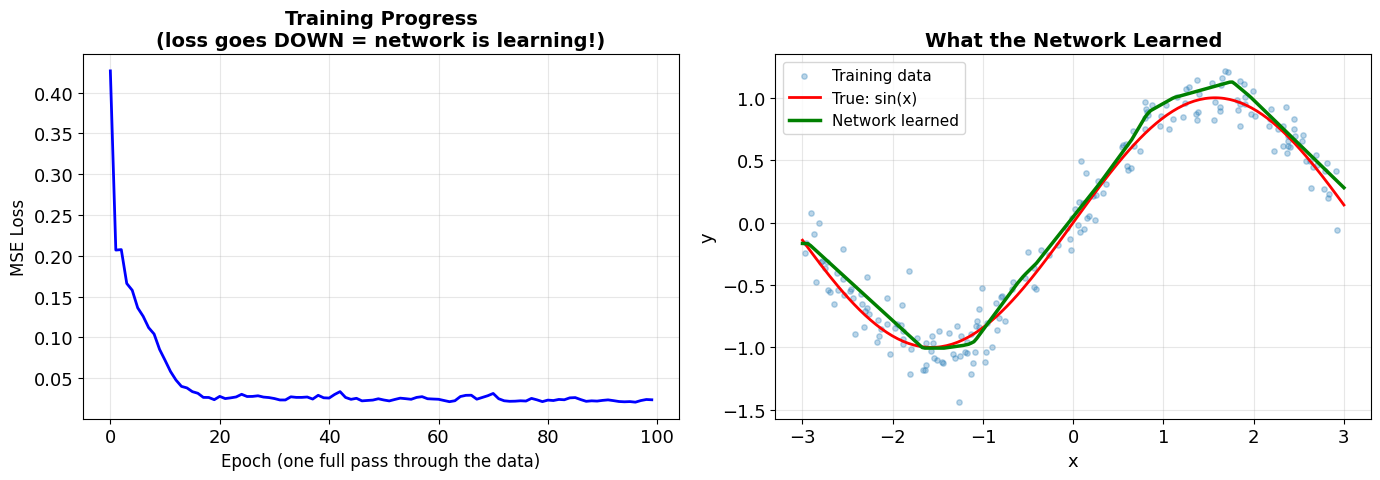

Final MSE loss: 0.0235
The network learned to approximate sin(x) from noisy data!


In [56]:
# === TRAIN THE MODEL ===
# This one line runs the ENTIRE training loop:
# forward pass → MSE loss → backpropagation → gradient descent → repeat
print("Training the regression model...")
print("(Watch the loss decrease — the network is learning!)\n")

history_reg = regression_model.fit(
    X_reg, y_reg,
    epochs=100,          # How many times to go through the entire dataset
    batch_size=32,       # How many examples to use per gradient descent step
    verbose=0            # Don't print every epoch (we'll plot it instead)
)

# Plot the training loss over time
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: loss over time
ax = axes[0]
ax.plot(history_reg.history['loss'], 'b-', linewidth=2)
ax.set_xlabel("Epoch (one full pass through the data)", fontsize=12)
ax.set_ylabel("MSE Loss", fontsize=12)
ax.set_title("Training Progress\n(loss goes DOWN = network is learning!)", fontsize=14, fontweight='bold')

# Right: the learned function
ax = axes[1]
ax.scatter(X_reg, y_reg, alpha=0.3, s=15, label='Training data')
ax.plot(x_smooth, np.sin(x_smooth), 'r-', linewidth=2, label='True: sin(x)')
y_pred_reg = regression_model.predict(x_smooth, verbose=0)
ax.plot(x_smooth, y_pred_reg, 'g-', linewidth=2.5, label='Network learned')
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("What the Network Learned", fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('part5_regression.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Final MSE loss: {history_reg.history['loss'][-1]:.4f}")
print("The network learned to approximate sin(x) from noisy data!")

### Step 5.2: Binary Classification: Using Cross-Entropy Loss

Now let's do **binary classification** with the loss function from Part 2. We'll use the "moons" dataset, which creates two crescent shapes that can't be separated with a straight line:

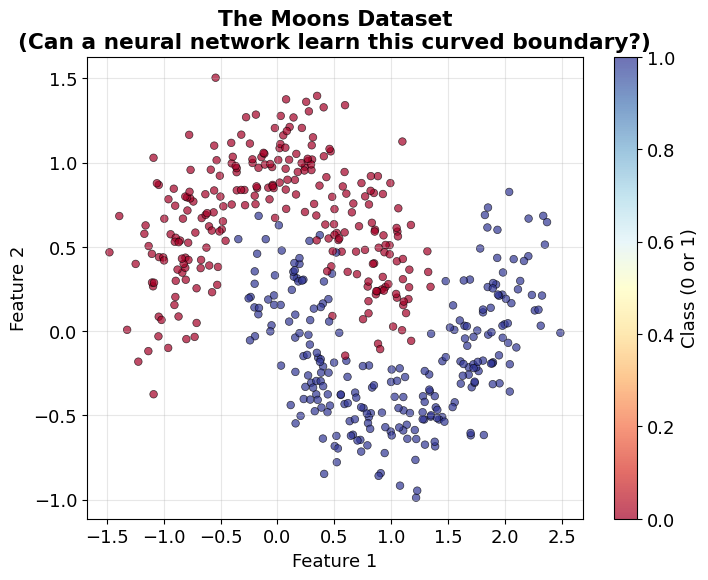

Challenge: these two classes CANNOT be separated by a straight line.
That's why we need a neural network (not just a perceptron)!


In [57]:
# === BINARY CLASSIFICATION: The Moons Dataset ===
from sklearn.datasets import make_moons

# Generate the data
X_moons, y_moons = make_moons(500, noise=0.2, random_state=42)

# Visualise
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons,
                      cmap='RdYlBu', s=30, alpha=0.7, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Class (0 or 1)')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("The Moons Dataset\n(Can a neural network learn this curved boundary?)", fontweight='bold')
plt.show()

print("Challenge: these two classes CANNOT be separated by a straight line.")
print("That's why we need a neural network (not just a perceptron)!")

In [58]:
# === BUILD A CLASSIFICATION NETWORK ===
classification_model = keras.Sequential([
    layers.Dense(8, activation='relu', input_shape=(2,)),    # Hidden layer 1
    layers.Dense(8, activation='relu'),                       # Hidden layer 2
    layers.Dense(1, activation='sigmoid')                     # Output: P(class=1) between 0 and 1
])

# Compile with BINARY CROSS-ENTROPY loss (from Part 2!)
classification_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss='binary_crossentropy',    # ← Binary cross-entropy from Part 2!
    metrics=['accuracy']           # Also track accuracy so we can see % correct
)

print("Our Classification Network:")
print("=" * 55)
classification_model.summary()
print()
print("Key takeaways:")
print("  • loss='binary_crossentropy'  →  From Part 2!")
print("  • activation='sigmoid' on output  →  Squashes to [0,1] = probability")
print("  • metrics=['accuracy']  →  Extra info: what % of predictions are correct")

Our Classification Network:


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_42 (Dense)                │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105 (420.00 B)

 Trainable params: 105 (420.00 B)

 Non-trainable params: 0 (0.00 B)


Key connections to the lecture:
  • loss='binary_crossentropy'  →  From Part 2!
  • activation='sigmoid' on output  →  Squashes to [0,1] = probability
  • metrics=['accuracy']  →  Extra info: what % of predictions are correct


Training the classification model...



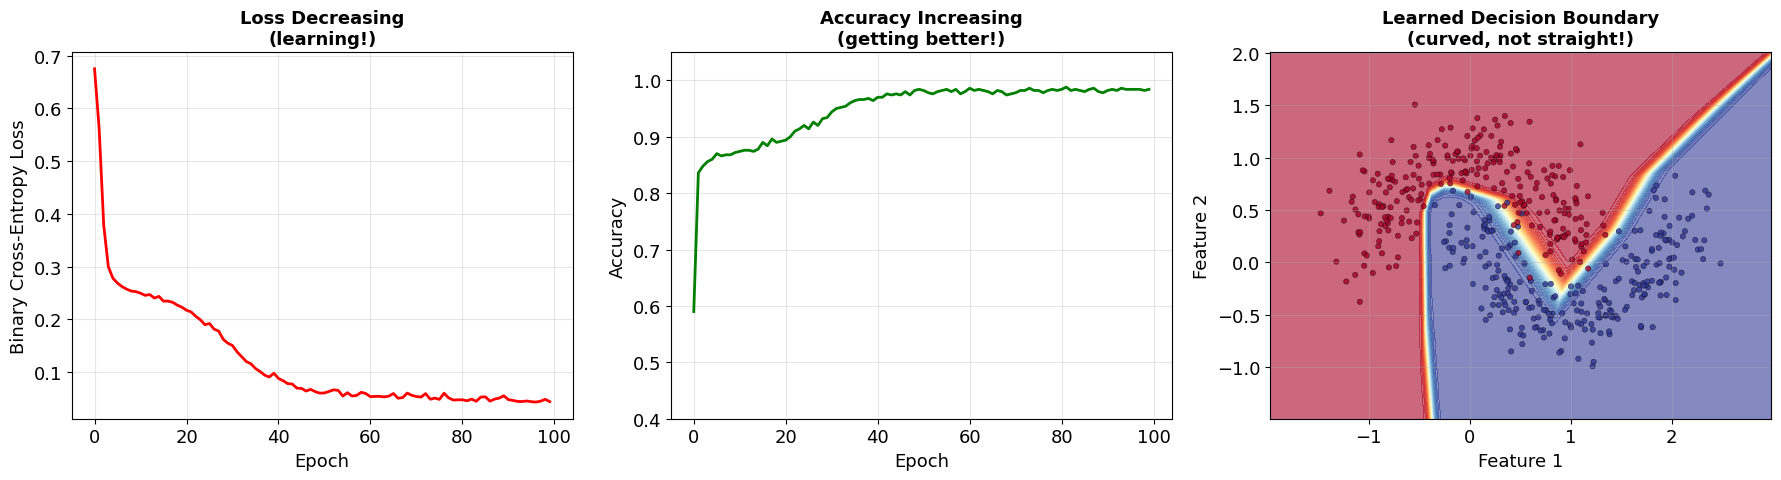

Final accuracy: 98.4%

The network learned a CURVED decision boundary using nonlinear activations,
just as the lecture described!


In [59]:
# === TRAIN THE CLASSIFIER ===
print("Training the classification model...\n")

history_clf = classification_model.fit(
    X_moons, y_moons,
    epochs=100,
    batch_size=32,
    verbose=0
)

# Plot: training progress AND the decision boundary
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Loss over time
ax = axes[0]
ax.plot(history_clf.history['loss'], 'r-', linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Binary Cross-Entropy Loss")
ax.set_title("Loss Decreasing\n(learning!)", fontsize=13, fontweight='bold')

# Plot 2: Accuracy over time
ax = axes[1]
ax.plot(history_clf.history['accuracy'], 'g-', linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy Increasing\n(getting better!)", fontsize=13, fontweight='bold')
ax.set_ylim(0.4, 1.05)

# Plot 3: Decision boundary
ax = axes[2]
# Create a mesh grid
x_min, x_max = X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5
y_min, y_max = X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                      np.linspace(y_min, y_max, 200))
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = classification_model.predict(grid_points, verbose=0).reshape(xx.shape)

ax.contourf(xx, yy, Z, levels=50, cmap='RdYlBu', alpha=0.6)
ax.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='RdYlBu',
           s=15, alpha=0.8, edgecolors='k', linewidth=0.3)
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("Learned Decision Boundary\n(curved, not straight!)", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('part5_classification.png', dpi=100, bbox_inches='tight')
plt.show()

final_acc = history_clf.history['accuracy'][-1]
print(f"Final accuracy: {final_acc:.1%}")
print("\nThe network learned a CURVED decision boundary using nonlinear activations,")
print("just as expected!")

### Step 5.3: Multi-Class Classification: Softmax + Cross-Entropy

Finally, let's do **multi-class classification** (more than 2 classes), using softmax and cross-entropy from Part 3. We'll classify a dataset with 3 classes:

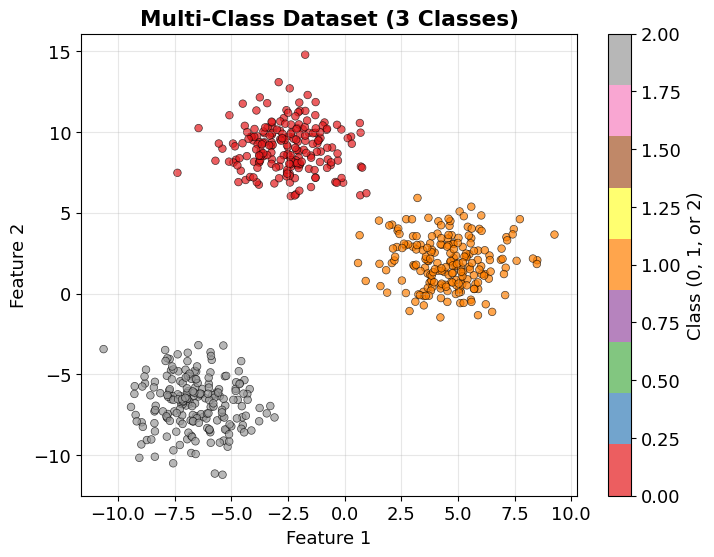

This time we have THREE classes — just like the cat/panda/koala example!


In [60]:
# === MULTI-CLASS CLASSIFICATION: 3 Classes ===
from sklearn.datasets import make_blobs

# Generate 3-class data
X_multi, y_multi = make_blobs(n_samples=600, centers=3, cluster_std=1.5, random_state=42)

# Visualise
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_multi[:, 0], X_multi[:, 1], c=y_multi,
                      cmap='Set1', s=30, alpha=0.7, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Class (0, 1, or 2)')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Multi-Class Dataset (3 Classes)", fontweight='bold')
plt.show()

print("This time we have THREE classes — just like the cat/panda/koala example!")

In [61]:
# === BUILD A MULTI-CLASS NETWORK ===
multiclass_model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(2,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(3, activation='softmax')    # ← SOFTMAX for multi-class! (from Part 3!)
])

# Compile with SPARSE CATEGORICAL CROSS-ENTROPY
# ("sparse" just means our labels are integers like 0,1,2 instead of one-hot vectors)
multiclass_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',   # ← Cross-entropy from Part 3!
    metrics=['accuracy']
)

print("Multi-Class Network:")
print("=" * 55)
multiclass_model.summary()
print()
print("Key takeaways:")
print("  • 3 output nodes with activation='softmax'  →  Outputs probabilities summing to 1!")
print("  • loss='sparse_categorical_crossentropy'  →  The multi-class cross-entropy from Part 3!")
print("  • This is exactly: -log(probability assigned to the correct class)")

Multi-Class Network:


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_45 (Dense)                │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)


Key connections to the lecture:
  • 3 output nodes with activation='softmax'  →  Outputs probabilities summing to 1!
  • loss='sparse_categorical_crossentropy'  →  The multi-class cross-entropy from Part 3!
  • This is exactly: -log(probability assigned to the correct class)


Training the multi-class model...



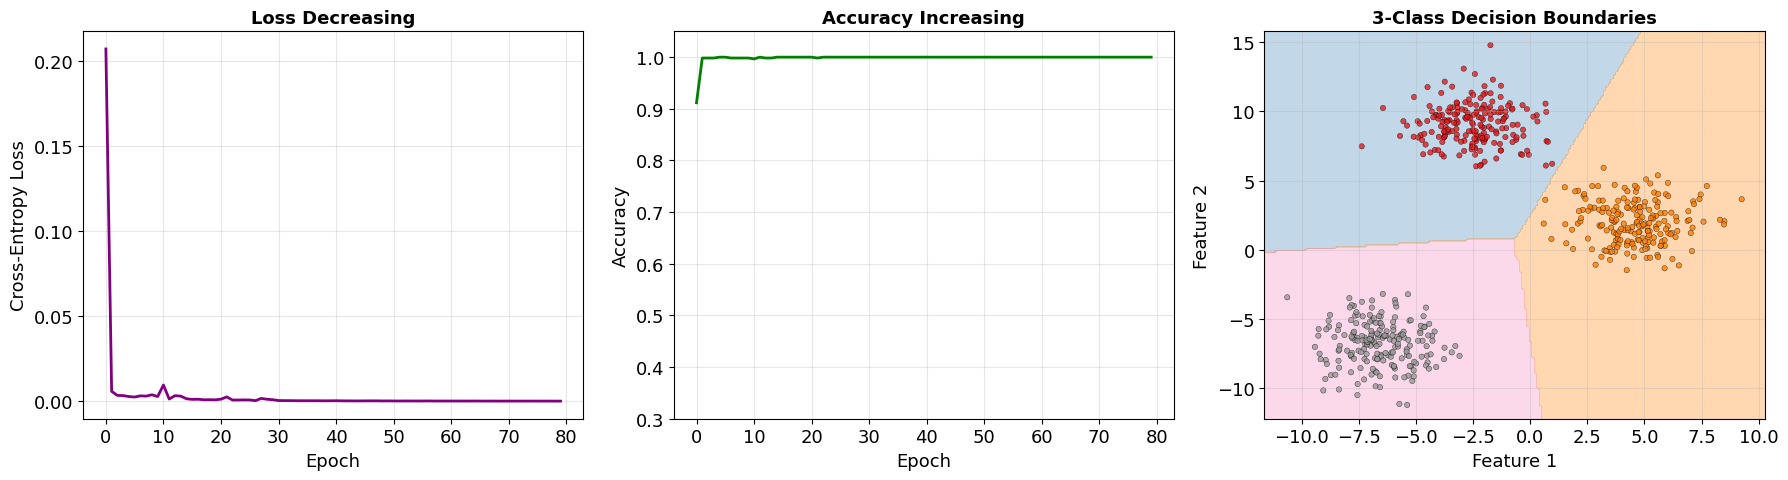

Example point: [3.47919504 0.10618763]
Softmax output: [2.5123148e-07 9.9999976e-01 2.3532734e-09]
Probabilities sum to: 1.0000
Predicted class: 1 (with 100.0% confidence)


In [62]:
# === TRAIN THE MULTI-CLASS MODEL ===
print("Training the multi-class model...\n")

history_multi = multiclass_model.fit(
    X_multi, y_multi,
    epochs=80,
    batch_size=32,
    verbose=0
)

# Plot results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
ax = axes[0]
ax.plot(history_multi.history['loss'], 'purple', linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")
ax.set_title("Loss Decreasing", fontsize=13, fontweight='bold')

# Accuracy
ax = axes[1]
ax.plot(history_multi.history['accuracy'], 'green', linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy Increasing", fontsize=13, fontweight='bold')
ax.set_ylim(0.3, 1.05)

# Decision boundaries
ax = axes[2]
x_min, x_max = X_multi[:, 0].min() - 1, X_multi[:, 0].max() + 1
y_min, y_max = X_multi[:, 1].min() - 1, X_multi[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                      np.linspace(y_min, y_max, 200))
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = multiclass_model.predict(grid_points, verbose=0).argmax(axis=1).reshape(xx.shape)

ax.contourf(xx, yy, Z, levels=2, cmap='Set1', alpha=0.3)
ax.scatter(X_multi[:, 0], X_multi[:, 1], c=y_multi, cmap='Set1',
           s=15, alpha=0.8, edgecolors='k', linewidth=0.3)
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("3-Class Decision Boundaries", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('part5_multiclass.png', dpi=100, bbox_inches='tight')
plt.show()

# Show softmax output for one example
example = X_multi[0:1]
probs = multiclass_model.predict(example, verbose=0)[0]
print(f"Example point: {example[0]}")
print(f"Softmax output: {probs}")
print(f"Probabilities sum to: {probs.sum():.4f}")
print(f"Predicted class: {probs.argmax()} (with {probs.max():.1%} confidence)")

---
### The Loss Function Cheat Sheet

Here's a summary that connects everything to Keras code:

| Problem Type | Output Activation | Loss Function | Keras `loss=` | Example |
|:---|:---|:---|:---|:---|
| **Regression** (predict a number) | `linear` (none) | Mean Squared Error | `'mse'` | Predicting exam scores |
| **Binary classification** (2 classes) | `sigmoid` | Binary Cross-Entropy | `'binary_crossentropy'` | Spam vs not spam |
| **Multi-class** (3+ classes) | `softmax` | Categorical Cross-Entropy | `'sparse_categorical_crossentropy'` | Cat vs panda vs koala |

**The pattern:**
- The **output activation** determines the *shape* of the output (probability, number, etc.)
- The **loss function** determines how we *measure* the error
- **Gradient descent** (with a learning rate) is always how we *improve* the weights

---
### ✏️ Exercise 4: Experiment with Keras Networks

Now it's your turn! Modify the networks and see what happens. For each experiment, pay attention to the **loss curve** (does it go down smoothly? does it get stuck? does it explode?).

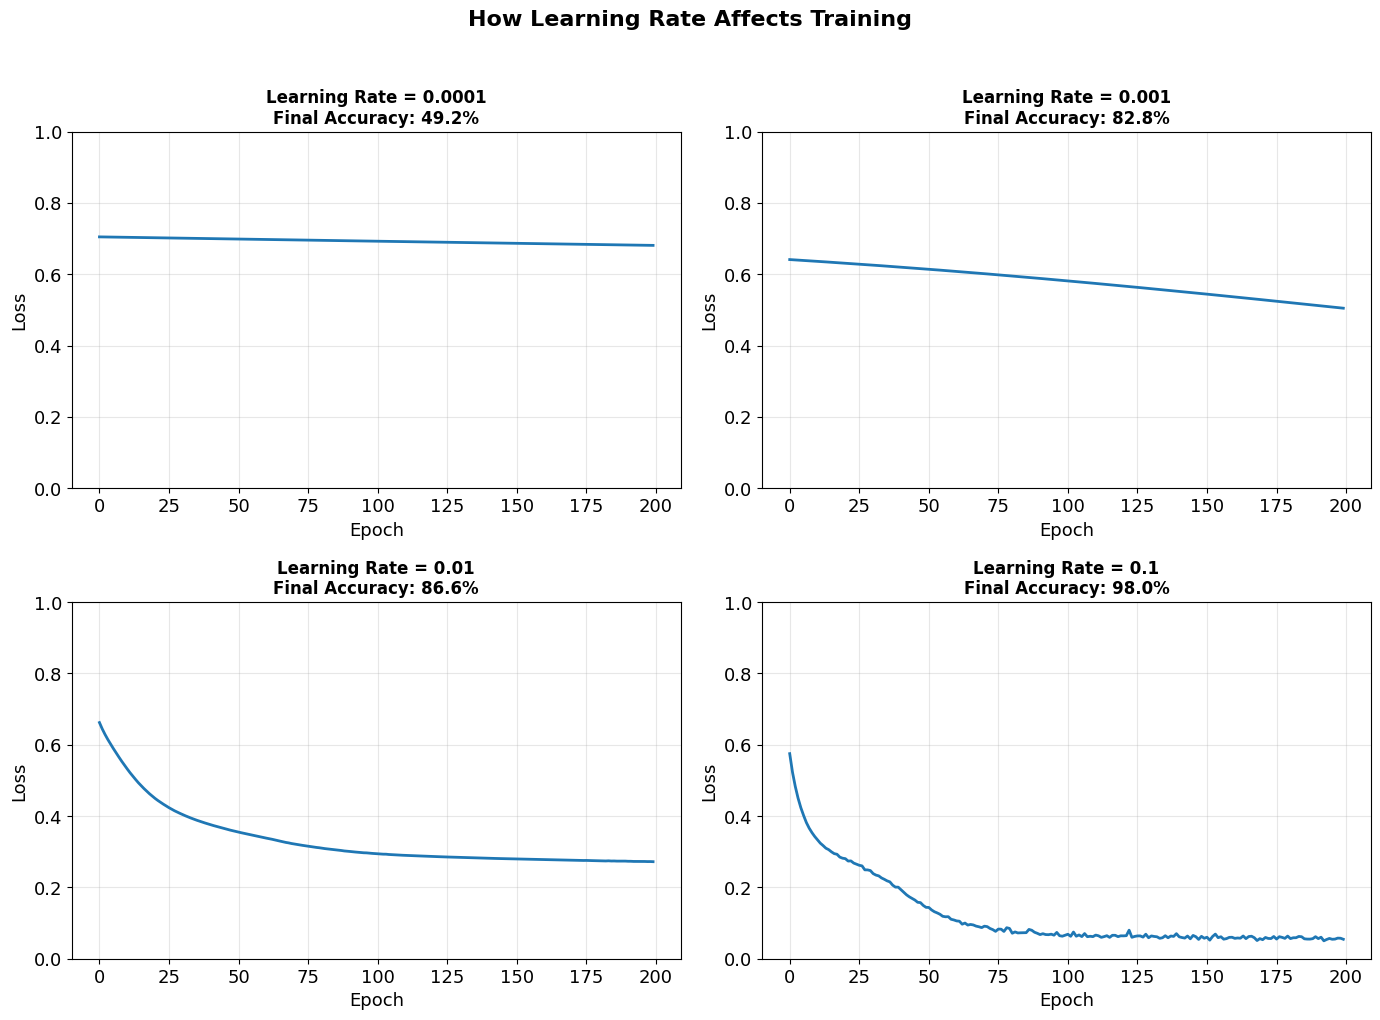

In [63]:
# EXERCISE 4a: Try different learning rates on the moons classification task
# Change the learning rate and observe the effect on the loss curve

learning_rates_to_try = [0.0001, 0.001, 0.01, 0.1]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, lr in enumerate(learning_rates_to_try):
    ax = axes[idx // 2, idx % 2]

    # Build and train a fresh model
    model = keras.Sequential([
        layers.Dense(8, activation='relu', input_shape=(2,)),
        layers.Dense(8, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=keras.optimizers.SGD(learning_rate=lr),  # Using basic SGD here
                  loss='binary_crossentropy', metrics=['accuracy'])

    history = model.fit(X_moons, y_moons, epochs=200, batch_size=32, verbose=0)

    ax.plot(history.history['loss'], linewidth=2)
    final_acc = history.history['accuracy'][-1]
    ax.set_title(f"Learning Rate = {lr}\nFinal Accuracy: {final_acc:.1%}",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_ylim(0, 1.0)

plt.suptitle("How Learning Rate Affects Training", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('exercise4_learning_rates.png', dpi=100, bbox_inches='tight')
plt.show()

Experiment: What if we use MSE loss for a classification problem?


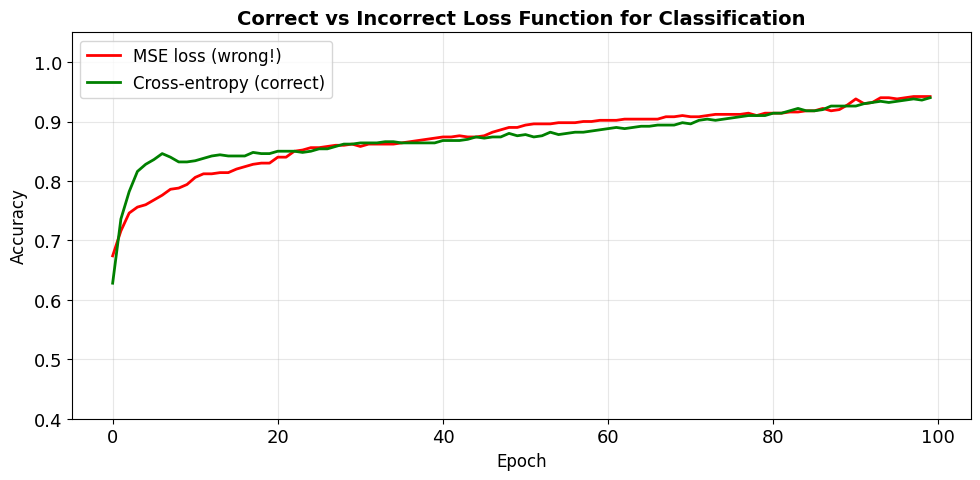

MSE loss final accuracy: 94.2%
Cross-entropy final accuracy: 94.0%

Using the right loss function matters!


In [64]:
# EXERCISE 4b: What happens if you use the WRONG loss function?
# Try using MSE for classification — does it still work?

print("Experiment: What if we use MSE loss for a classification problem?")
print("=" * 60)

# Wrong loss (MSE for classification)
model_wrong = keras.Sequential([
    layers.Dense(8, activation='relu', input_shape=(2,)),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
model_wrong.compile(optimizer='adam', loss='mse', metrics=['accuracy'])
history_wrong = model_wrong.fit(X_moons, y_moons, epochs=100, batch_size=32, verbose=0)

# Right loss (binary cross-entropy)
model_right = keras.Sequential([
    layers.Dense(8, activation='relu', input_shape=(2,)),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
model_right.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_right = model_right.fit(X_moons, y_moons, epochs=100, batch_size=32, verbose=0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history_wrong.history['accuracy'], 'r-', linewidth=2, label='MSE loss (wrong!)')
ax.plot(history_right.history['accuracy'], 'g-', linewidth=2, label='Cross-entropy (correct)')
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Correct vs Incorrect Loss Function for Classification", fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.set_ylim(0.4, 1.05)
plt.tight_layout()
plt.savefig('exercise4_wrong_loss.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"MSE loss final accuracy: {history_wrong.history['accuracy'][-1]:.1%}")
print(f"Cross-entropy final accuracy: {history_right.history['accuracy'][-1]:.1%}")
print("\nUsing the right loss function matters!")

In [65]:
# EXERCISE 4c: Write your observations
#
# What happened when the learning rate was too small (0.0001)?
#
#
# What happened when the learning rate was too large (0.1 with SGD)?
#
#
# What happened when you used MSE instead of cross-entropy for classification?
#
#
# Why do you think the choice of loss function matters?
# (Hint: think about the shapes of the loss curves from Part 2)
#
# 

---
### ✏️ Exercise 5: Network Architecture: How Many Neurons?

The **architecture** (number of hidden layers and neurons per layer) controls how complex a function the network can learn. Let's see this in action:

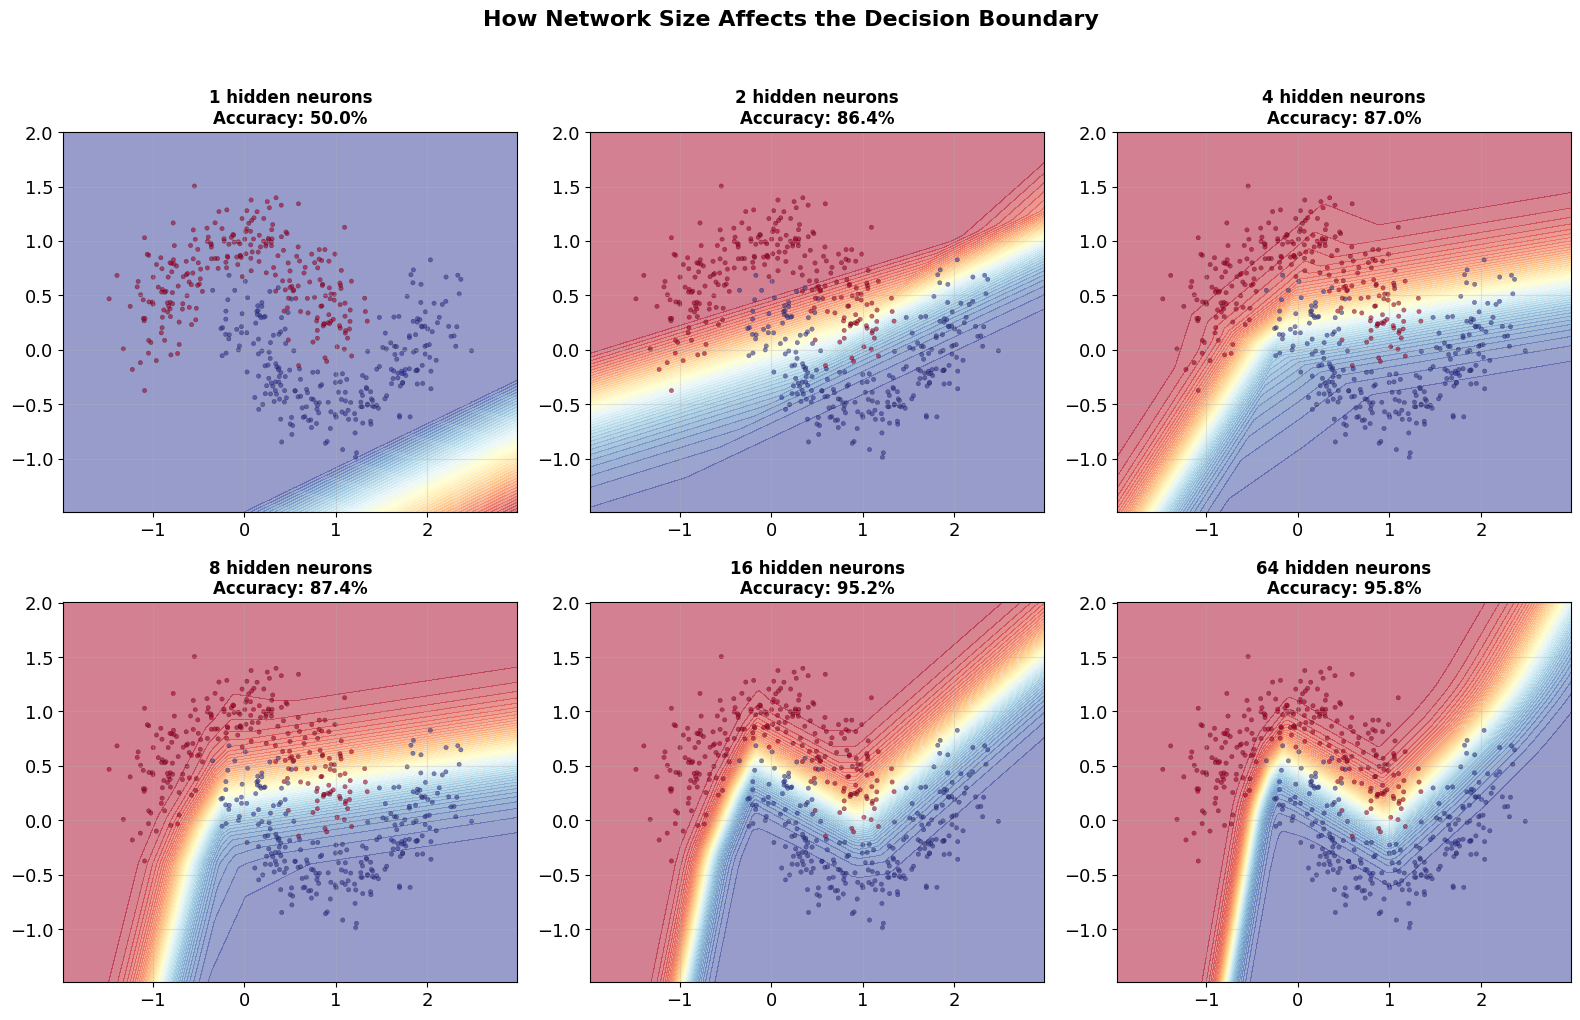

Notice: more neurons = more complex boundaries!
But be careful — too many neurons can 'memorise' the noise (overfitting)


In [66]:
# EXERCISE 5: How does hidden layer size affect the decision boundary?

hidden_sizes = [1, 2, 4, 8, 16, 64]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for idx, h_size in enumerate(hidden_sizes):
    ax = axes[idx // 3, idx % 3]

    # Build model with different hidden sizes
    model = keras.Sequential([
        layers.Dense(h_size, activation='relu', input_shape=(2,)),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    model.fit(X_moons, y_moons, epochs=200, batch_size=32, verbose=0)

    # Plot decision boundary
    Z = model.predict(grid_points[:, :2] if grid_points.shape[1] > 2 else
                      np.c_[np.meshgrid(
                          np.linspace(X_moons[:, 0].min()-0.5, X_moons[:, 0].max()+0.5, 200),
                          np.linspace(X_moons[:, 1].min()-0.5, X_moons[:, 1].max()+0.5, 200)
                      )[0].ravel(),
                      np.meshgrid(
                          np.linspace(X_moons[:, 0].min()-0.5, X_moons[:, 0].max()+0.5, 200),
                          np.linspace(X_moons[:, 1].min()-0.5, X_moons[:, 1].max()+0.5, 200)
                      )[1].ravel()], verbose=0)

    xx2, yy2 = np.meshgrid(
        np.linspace(X_moons[:, 0].min()-0.5, X_moons[:, 0].max()+0.5, 200),
        np.linspace(X_moons[:, 1].min()-0.5, X_moons[:, 1].max()+0.5, 200))
    Z2 = model.predict(np.c_[xx2.ravel(), yy2.ravel()], verbose=0).reshape(xx2.shape)

    acc = model.evaluate(X_moons, y_moons, verbose=0)[1]

    ax.contourf(xx2, yy2, Z2, levels=50, cmap='RdYlBu', alpha=0.5)
    ax.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='RdYlBu',
               s=10, alpha=0.6, edgecolors='k', linewidth=0.2)
    ax.set_title(f"{h_size} hidden neurons\nAccuracy: {acc:.1%}",
                 fontsize=12, fontweight='bold')

plt.suptitle("How Network Size Affects the Decision Boundary",
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('exercise5_hidden_sizes.png', dpi=100, bbox_inches='tight')
plt.show()

print("Notice: more neurons = more complex boundaries!")
print("But be careful — too many neurons can 'memorise' the noise (overfitting)")

In [67]:
# EXERCISE 5: Write your observations
#
# With 1 hidden neuron, the decision boundary is...
#
#
# With 64 hidden neurons, the decision boundary is...
#
#
# What's the 'sweet spot' — enough neurons to learn the pattern but not too many?
#
#
# Think about it: why do nonlinear activations (ReLU) allow
# curved decision boundaries, while linear activations can only do straight lines?
#
# 

---
## Part 6: Reflection & Summary

### What You've Learned

You've now understood the complete neural network training loop:

| Lecture Topic | What It Does | Lab Section | Keras Connection |
|:---|:---|:---|:---|
| **Loss (regression)** | Measures error as MSE, where squaring punishes big mistakes | Part 1 | `loss='mse'` |
| **Loss (binary classification)** | Measures error as binary cross-entropy, which punishes confident wrong answers | Part 2 | `loss='binary_crossentropy'` |
| **Softmax + cross-entropy** | Turns scores into probabilities, measures multi-class error | Part 3 | `activation='softmax'` + `loss='sparse_categorical_crossentropy'` |
| **Gradient descent** | Uses the slope (gradient) to update weights toward lower loss | Part 4 | `optimizer=SGD(learning_rate=...)` |
| **Learning rate** | Controls step size: too small = slow, too large = unstable | Parts 4 & 5 | `learning_rate=0.01` |
| **Architecture** | Number of layers and neurons controls model complexity | Part 5 | `Dense(8, activation='relu')` |

---
### ✏️ Final Exercise: Connect the Concepts

**Exercise 6a:** Imagine a friend who missed these lectures asks you: *"What is a loss function and why do we need one?"* Explain it in 2–3 sentences using plain language.

**Exercise 6b:** Same friend asks: *"What is gradient descent?"* Explain it using the "lost in fog on a mountain" analogy.

**Exercise 6c:** Why can't we just use MSE for everything, for both regression AND classification? What goes wrong?

In [68]:
# EXERCISE 6: Your explanations
#
# 6a: What is a loss function?
# "A loss function is..."
#
#
# 6b: What is gradient descent?
# "Imagine you're standing on a hilly landscape in thick fog..."
#
#
# 6c: Why can't we use MSE for classification?
# "MSE doesn't work well for classification because..."
#
# 

---
### Bonus Challenges (Optional)

If you want to go deeper:

1. **The Iris Dataset:** Load the famous Iris flower dataset (`from sklearn.datasets import load_iris`) and build a 3-class classifier. What loss function and output activation should you use?

2. **Visualise Softmax:** Write code that takes a vector of 3 raw scores and shows a bar chart of the softmax probabilities. Try different input scores and see how softmax "picks a winner."

3. **Learning Rate Schedules:** What if we started with a large learning rate and gradually made it smaller? Try `keras.optimizers.schedules.ExponentialDecay`. Does it help?